# TimeGAN baseline aligned with Conv1D Hybrid Detector — v2


In [1]:
import os
import json
import math
import joblib
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


## Reproducibilidad y dispositivo


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Cargar configuración del detector


In [3]:
PROJECT_ROOT = Path("..").resolve()

detector_config_path = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json"
with open(detector_config_path, "r") as f:
    detector_config = json.load(f)

detector_config


{'model_name': 'conv1d_hybrid_ae',
 'best_params_from_optuna': {'window_size': 60,
  'stride': 1,
  'n_conv_layers': 1,
  'conv_channels_1': 64,
  'conv_channels_2': 16,
  'conv_channels_3': 8,
  'kernel_size': 5,
  'disc_hidden_1': 64,
  'disc_hidden_2': 16,
  'fusion_hidden': 256,
  'dropout': 0.01837443752413843,
  'batch_size': 128,
  'lr': 0.00023729585064585673,
  'optimizer': 'Adam',
  'epochs': 30},
 'continuous_cols': ['AIT201.Pv',
  'AIT202.Pv',
  'AIT203.Pv',
  'AIT501.Pv',
  'AIT502.Pv',
  'AIT503.Pv',
  'AIT504.Pv',
  'DPIT301.Pv',
  'FIT101.Pv',
  'FIT201.Pv',
  'FIT301.Pv',
  'FIT401.Pv',
  'FIT501.Pv',
  'FIT502.Pv',
  'FIT503.Pv',
  'FIT504.Pv',
  'FIT601.Pv',
  'LIT101.Pv',
  'LIT301.Pv',
  'LIT401.Pv',
  'PIT501.Pv',
  'PIT502.Pv',
  'PIT503.Pv'],
 'discrete_cols': ['MV101.Status',
  'MV201.Status',
  'MV301.Status',
  'MV302.Status',
  'MV303.Status',
  'MV304.Status',
  'MV501.Status',
  'MV502.Status',
  'MV503.Status',
  'MV504.Status',
  'P101.Status',
  'P201.S

In [4]:
continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]

WINDOW_SIZE = detector_config["window_size"]
STRIDE      = detector_config["stride"]
WARMUP      = detector_config["warmup"]

# FIX v2: stride para TimeGAN es independiente del stride del detector.
# stride=5 produce ventanas con 92% de solapamiento (55/60 timesteps iguales).
# El dataset sigue siendo altamente redundante y el modelo memoriza estructuras locales.
# Se usa stride = WINDOW_SIZE // 3 como compromiso entre diversidad y volumen.
TIMEGAN_STRIDE = max(WINDOW_SIZE // 3, 1)  # ~20 para window_size=60

print("Window size:", WINDOW_SIZE)
print("Stride detector:", STRIDE)
print("Stride TimeGAN:", TIMEGAN_STRIDE)
print("Warmup:", WARMUP)
print("Continuous:", len(continuous_cols))
print("Discrete:", len(discrete_cols))


Window size: 60
Stride detector: 1
Stride TimeGAN: 20
Warmup: 120
Continuous: 23
Discrete: 26


## Cargar y preparar datos


In [5]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"
file_paths = sorted(clean_folder.glob("*.csv"))

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {fp.stem: load_clean_csv(fp) for fp in file_paths}
print("Archivos cargados:", list(files.keys()))


Archivos cargados: ['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']


In [6]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {name: df[common_cols].copy() for name, df in files.items()}
print("Columnas comunes:", len(common_cols))


Columnas comunes: 61


In [7]:
temp_feature_cols = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    before = len(files[name])
    files[name] = files[name].dropna(subset=temp_feature_cols, how="all").reset_index(drop=True)
    after = len(files[name])
    if before != after:
        print(f"{name}: {before - after} filas eliminadas")


29June2020_2: 1 filas eliminadas


In [8]:
global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0).reset_index(drop=True)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]

for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols

print("Continuas:", len(continuous_cols), "| Discretas:", len(discrete_cols))


Continuas: 23 | Discretas: 26


In [9]:
def remove_warmup(df, warmup_seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    start_time = df["t_stamp"].min()
    return df[df["t_stamp"] >= start_time + pd.Timedelta(seconds=warmup_seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], warmup_seconds=WARMUP)


## Split temporal


In [10]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

split_by_file = {}
for name, df_i in files.items():
    df_base = df_i[["t_stamp"] + feature_cols].copy()
    train_i, val_i, test_i = temporal_split(df_base)
    split_by_file[name] = {"train": train_i, "val": val_i, "test": test_i}
    print(f"{name}: train={train_i.shape}, val={val_i.shape}, test={test_i.shape}")


22June2020_1: train=(8568, 50), val=(2856, 50), test=(2856, 50)
22June2020_2: train=(2088, 50), val=(696, 50), test=(696, 50)
29June2020_1: train=(4248, 50), val=(1416, 50), test=(1417, 50)
29June2020_2: train=(4248, 50), val=(1416, 50), test=(1416, 50)


## Escalado


In [11]:
scaler_cont_detector = StandardScaler()
scaler_cont_timegan  = MinMaxScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)
scaler_cont_timegan.fit(train_all_cont)


,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [12]:
def scale_split_part(df_part, scaler, continuous_cols, discrete_cols):
    cont = pd.DataFrame(
        scaler.transform(df_part[continuous_cols]),
        columns=continuous_cols, index=df_part.index
    )
    disc = df_part[discrete_cols].copy()
    return cont, disc

scaled_split_by_file = {}
for name in split_by_file:
    scaled_split_by_file[name] = {}
    for subset in ["train", "val", "test"]:
        c, d = scale_split_part(
            split_by_file[name][subset], scaler_cont_timegan, continuous_cols, discrete_cols
        )
        scaled_split_by_file[name][subset] = {"cont": c, "disc": d}


## Catálogo discretas y one-hot


In [13]:
train_disc_global = pd.concat(
    [scaled_split_by_file[name]["train"]["disc"] for name in scaled_split_by_file], axis=0
).reset_index(drop=True)

discrete_value_maps = {
    col: sorted(pd.Series(train_disc_global[col]).dropna().unique().tolist())
    for col in discrete_cols
}

onehot_sizes = {col: len(discrete_value_maps[col]) for col in discrete_cols}
total_disc_onehot_dim = sum(onehot_sizes.values())
print("Total one-hot dim discretas:", total_disc_onehot_dim)


Total one-hot dim discretas: 91


In [14]:
def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        encoded_t = []
        for j, col in enumerate(discrete_cols):
            value = disc_array[t, j]
            categories = discrete_value_maps[col]
            onehot = np.zeros(len(categories), dtype=np.float32)
            if value in categories:
                onehot[categories.index(value)] = 1.0
            encoded_t.extend(onehot.tolist())
        rows.append(encoded_t)
    return np.array(rows, dtype=np.float32)


## Construcción de ventanas para TimeGAN

**FIX v2 — stride independiente para TimeGAN:**  
Se usa `TIMEGAN_STRIDE = WINDOW_SIZE // 3` (~20) en lugar del stride=5 original.  
Con stride=5, el 92% de cada ventana es idéntica a la siguiente, creando un dataset  
con alta correlación entre ejemplos. Esto hace que el modelo aprenda el promedio local  
de la serie en lugar de su distribución global, y el t-SNE lo revela como una curva  
colapsada en lugar de una nube que solape con los datos reales.


In [15]:
def build_windows_for_timegan(
    scaled_split_by_file, subset, continuous_cols, discrete_cols,
    discrete_value_maps, window_size=60, stride=20
):
    cont_windows, disc_windows_raw, disc_windows_onehot, origin_tracker = [], [], [], []

    for name in scaled_split_by_file:
        cont_df = scaled_split_by_file[name][subset]["cont"]
        disc_df = scaled_split_by_file[name][subset]["disc"]

        if len(cont_df) < window_size:
            continue

        cont_arr = cont_df.values.astype(np.float32)
        disc_arr = disc_df.values

        for i in range(0, len(cont_df) - window_size + 1, stride):
            cont_w = cont_arr[i:i+window_size]
            disc_w = disc_arr[i:i+window_size]
            disc_w_onehot = one_hot_encode_discrete_sequence(disc_w, discrete_cols, discrete_value_maps)
            cont_windows.append(cont_w)
            disc_windows_raw.append(disc_w)
            disc_windows_onehot.append(disc_w_onehot)
            origin_tracker.append(name)

    if not cont_windows:
        return None

    return (
        np.array(cont_windows, dtype=np.float32),
        np.array(disc_windows_raw, dtype=object),
        np.array(disc_windows_onehot, dtype=np.float32),
        origin_tracker
    )


In [16]:
train_pack = build_windows_for_timegan(
    scaled_split_by_file, "train", continuous_cols, discrete_cols,
    discrete_value_maps, WINDOW_SIZE, TIMEGAN_STRIDE
)
val_pack = build_windows_for_timegan(
    scaled_split_by_file, "val", continuous_cols, discrete_cols,
    discrete_value_maps, WINDOW_SIZE, TIMEGAN_STRIDE
)
test_pack = build_windows_for_timegan(
    scaled_split_by_file, "test", continuous_cols, discrete_cols,
    discrete_value_maps, WINDOW_SIZE, TIMEGAN_STRIDE
)

train_cont_windows, train_disc_windows_raw, train_disc_windows_onehot, train_origin = train_pack
val_cont_windows,   val_disc_windows_raw,   val_disc_windows_onehot,   val_origin   = val_pack
test_cont_windows,  test_disc_windows_raw,  test_disc_windows_onehot,  test_origin  = test_pack

print("Train cont windows:", train_cont_windows.shape)
print("Val   cont windows:", val_cont_windows.shape)
print("Test  cont windows:", test_cont_windows.shape)


Train cont windows: (948, 60, 23)
Val   cont windows: (308, 60, 23)
Test  cont windows: (308, 60, 23)


In [17]:
train_timegan_data = np.concatenate([train_cont_windows, train_disc_windows_onehot], axis=2)
val_timegan_data   = np.concatenate([val_cont_windows,   val_disc_windows_onehot],   axis=2)
test_timegan_data  = np.concatenate([test_cont_windows,  test_disc_windows_onehot],  axis=2)

print("Train TimeGAN data:", train_timegan_data.shape)
print("Val   TimeGAN data:", val_timegan_data.shape)
print("Test  TimeGAN data:", test_timegan_data.shape)


Train TimeGAN data: (948, 60, 114)
Val   TimeGAN data: (308, 60, 114)
Test  TimeGAN data: (308, 60, 114)


## DataLoader


In [18]:
BATCH_SIZE = 128

train_timegan_tensor = torch.tensor(train_timegan_data, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_timegan_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

print(f"Batches por época: {len(train_loader)}")


Batches por época: 7


## Hiperparámetros

**Resumen de los cambios críticos respecto a las versiones anteriores:**

| Parámetro | v0 original | v1 (fix anterior) | v2 (este fix) | Razón |
|-----------|-------------|-------------------|---------------|-------|
| `eta` | 200 | 10 | **10** | Mantenido. Fue el fix más importante. |
| `lambda_m` | 100 | 1 | **1** | Mantenido. Moment matching solo como regularización. |
| `lambda_r` | 10 | — | **1** | Tu versión lo mantiene; se corrige la forma de usarlo (ver loop joint). |
| `hidden_dim` | 64 | 64 | **128** | Mayor capacidad representacional para un dataset ICS complejo. |
| `epochs_emb` | 50 | 200 | **300** | Embedder bien entrenado = todo lo demás funciona mejor. |
| `epochs_sup` | 50 | 200 | **200** | Mantenido. |
| `epochs_joint`| 100 | 300 | **500** | Más entrenamiento adversarial necesario con datos diversos. |
| `stride` | 1 | 30 | **~20** | Balance entre diversidad y volumen. |
| `init t-SNE` | random | pca | **pca** | Mejor convergencia y reproducibilidad. |


In [19]:
seq_len     = WINDOW_SIZE
feature_dim = train_timegan_data.shape[2]

hidden_dim = 128   # FIX v2: mayor capacidad
latent_dim = 64
num_layers = 3

epochs_embedder  = 300  # FIX v2: embedder sólido es el cimiento de todo
epochs_supervisor = 200
epochs_joint     = 500  # FIX v2: más entrenamiento adversarial

gamma    = 1
eta      = 10    # Fix v1 mantenido
lambda_r = 1.0   # FIX v2: solo como coeficiente escalar, la lógica de uso cambia en el loop
lambda_s = 1.0
lambda_m = 1.0   # Fix v1 mantenido

print(f"Feature dim: {feature_dim}, seq_len: {seq_len}, hidden_dim: {hidden_dim}")


Feature dim: 114, seq_len: 60, hidden_dim: 128


## Arquitecturas de TimeGAN

**FIX v2 — Normalización de capas en Embedder y Recovery:**  
Se añade `LayerNorm` después del GRU en Embedder y Recovery. Esto estabiliza  
las activaciones del espacio latente, lo que es crítico para que el Supervisor  
y el Generator aprendan transiciones temporales consistentes.  
Sin normalización, el espacio latente puede tener distribuciones muy diferentes  
entre el path real (Embedder) y el path sintético (Generator+Supervisor),  
que es exactamente lo que el t-SNE revela como dos manifolds separados.


In [20]:
class Embedder(nn.Module):
    """Mapea X (feature space) -> H (latent space)"""
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)   # FIX v2: estabiliza el espacio latente
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        h    = self.norm(h)  # FIX v2
        return self.act(self.fc(h))


In [21]:
class Recovery(nn.Module):
    """Mapea H (latent) -> X_tilde (feature space)"""
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)   # FIX v2
        self.fc   = nn.Linear(hidden_dim, output_dim)
        self.act  = nn.Sigmoid()

    def forward(self, h):
        x_tilde, _ = self.rnn(h)
        x_tilde    = self.norm(x_tilde)  # FIX v2
        return self.act(self.fc(x_tilde))


In [22]:
class Generator(nn.Module):
    """Mapea Z (ruido) -> E_hat (latent space sintético)"""
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)   # FIX v2
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e_hat, _ = self.rnn(z)
        e_hat    = self.norm(e_hat)  # FIX v2
        return self.act(self.fc(e_hat))


In [23]:
class Supervisor(nn.Module):
    """Modela transiciones temporales en el espacio latente"""
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=max(1, num_layers - 1),
                          batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


In [24]:
class Discriminator(nn.Module):
    """Distingue H real de H_hat sintético"""
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y_hat, _ = self.rnn(h)
        return self.fc(y_hat)


In [25]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

total_params = sum(p.numel() for p in [
    *embedder.parameters(), *recovery.parameters(), *generator.parameters(),
    *supervisor.parameters(), *discriminator.parameters()
])
print(f"Total parámetros: {total_params:,}")


Total parámetros: 1,422,195


## Losses, optimizadores y auxiliares


In [26]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

# FIX v2: schedulers para decaer lr en fases largas
g_scheduler = torch.optim.lr_scheduler.StepLR(g_optimizer, step_size=100, gamma=0.5)
d_scheduler = torch.optim.lr_scheduler.StepLR(d_optimizer, step_size=100, gamma=0.5)


In [27]:
def random_generator(batch_size, seq_len, z_dim, device):
    return torch.rand(batch_size, seq_len, z_dim, device=device)

def moment_loss(y_true, y_pred):
    mean_loss = torch.mean(torch.abs(torch.mean(y_true, dim=0) - torch.mean(y_pred, dim=0)))
    var_loss  = torch.mean(torch.abs(torch.var(y_true, dim=0)  - torch.var(y_pred, dim=0)))
    return mean_loss + var_loss


## Fase 1: Entrenamiento del Embedder + Recovery

Esta fase es el cimiento de todo. Un embedder mal entrenado hace que las fases  
posteriores partan de un espacio latente incoherente. Se aumentan las épocas a 300  
y se monitorea que la pérdida converja por debajo de 0.05.


In [28]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()

        h      = embedder(x)
        x_tilde = recovery(h)

        e_loss_t0 = mse_loss(x_tilde, x)
        e_loss    = 10 * torch.sqrt(e_loss_t0 + 1e-8)

        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()
        epoch_loss += e_loss.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | Loss: {epoch_loss:.6f}")

print(f"[Embedder] Loss final: {embedder_history[-1]:.6f}")
print("NOTA: idealmente < 0.05 antes de continuar. Si no, considera más épocas.")


[Embedder] Epoch 50/300 | Loss: 0.336251
[Embedder] Epoch 100/300 | Loss: 0.203109
[Embedder] Epoch 150/300 | Loss: 0.123337
[Embedder] Epoch 200/300 | Loss: 0.088408
[Embedder] Epoch 250/300 | Loss: 0.071307
[Embedder] Epoch 300/300 | Loss: 0.062584
[Embedder] Loss final: 0.062584
NOTA: idealmente < 0.05 antes de continuar. Si no, considera más épocas.


## Fase 2: Entrenamiento del Supervisor


In [29]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()

        with torch.no_grad():
            h = embedder(x)

        h_hat_supervise = supervisor(h)
        s_loss = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])

        s_loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), max_norm=1.0)
        s_optimizer.step()
        epoch_loss += s_loss.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {epoch_loss:.6f}")


[Supervisor] Epoch 50/200 | Loss: 0.003940
[Supervisor] Epoch 100/200 | Loss: 0.003539
[Supervisor] Epoch 150/200 | Loss: 0.003382
[Supervisor] Epoch 200/200 | Loss: 0.003265


## Fase 3: Entrenamiento Conjunto

**FIX v2 — Los 3 cambios clave respecto a tu versión actual:**

**1. `torch.no_grad()` en el embedder durante el paso del generador.**  
En tu versión actual, `h = embedder(x)` dentro del loop del generador propaga  
gradientes al embedder desde `g_loss`. Esto desestabiliza el embedder que ya  
aprendió una buena representación en la fase 1.

**2. El embedder se actualiza una sola vez por batch, no dos.**  
Tu versión actual actualiza el embedder dentro del loop `for _ in range(2)`,  
es decir, 2 veces por batch. Esto rompe la coherencia del espacio latente porque  
el discriminador ve H calculados con dos versiones distintas del embedder en el  
mismo batch.

**3. El umbral del discriminador se corrige.**  
Tu versión mantiene `if d_loss > 0.15` que es demasiado alto. El discriminador  
necesita entrenarse siempre al inicio. Se cambia a `0.05` con clipping.


In [30]:
joint_g_history = []
joint_d_history = []
joint_e_history = []

for epoch in range(epochs_joint):
    g_epoch_loss = 0.0
    d_epoch_loss = 0.0
    e_epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)
        batch_size_curr = x.shape[0]

        # ----------------------------------------
        # 1) Calcular H real UNA SOLA VEZ por batch
        #    FIX v2: se calcula aquí con no_grad para
        #    usarlo en G, E y D sin recalcular
        # ----------------------------------------
        with torch.no_grad():
            h_real = embedder(x)

        # ----------------------------------------
        # 2) Train Generator + Supervisor (2 pasos)
        #    FIX v2: se usa h_real precomputado
        # ----------------------------------------
        for _ in range(2):
            g_optimizer.zero_grad()

            z     = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            x_hat = recovery(h_hat)

            y_fake   = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u   = bce_loss(y_fake,   torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            # Pérdida supervisada: supervisor aplicado sobre H real
            h_supervise = supervisor(h_real)
            g_loss_s    = mse_loss(h_real[:, 1:, :], h_supervise[:, :-1, :])

            # Moment matching entre x real y x sintético
            g_loss_v = moment_loss(x, x_hat)

            g_loss = g_loss_u + gamma * g_loss_u_e + eta * torch.sqrt(g_loss_s + 1e-8) + lambda_m * g_loss_v
            g_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), max_norm=1.0
            )
            g_optimizer.step()

        # ----------------------------------------
        # 3) Embedder refinement (UNA sola vez)
        #    FIX v2: no dentro del loop anterior
        #    FIX v2: lambda_r=1 aplicado correctamente
        #    (e_loss0 ya tiene el factor 10*sqrt interno)
        # ----------------------------------------
        e_optimizer.zero_grad()

        # Aquí sí calculamos h con gradiente (para actualizar el embedder)
        h_ref    = embedder(x)
        x_tilde  = recovery(h_ref)

        h_supervise_ref = supervisor(h_ref.detach())  # supervisor ya entrenado, no necesita gradiente
        g_loss_s_ref    = mse_loss(h_ref[:, 1:, :], h_supervise_ref[:, :-1, :])

        e_loss_t0 = mse_loss(x_tilde, x)
        e_loss0   = 10 * torch.sqrt(e_loss_t0 + 1e-8)

        # FIX v2: lambda_r=1 → sin doble multiplicación
        e_loss = lambda_r * e_loss0 + lambda_s * g_loss_s_ref

        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()

        # ----------------------------------------
        # 4) Train Discriminator
        #    FIX v2: umbral corregido a 0.05
        # ----------------------------------------
        d_optimizer.zero_grad()

        with torch.no_grad():
            z     = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

        y_real   = discriminator(h_real)
        y_fake   = discriminator(h_hat)
        y_fake_e = discriminator(e_hat)

        d_loss_real   = bce_loss(y_real,   torch.ones_like(y_real))
        d_loss_fake   = bce_loss(y_fake,   torch.zeros_like(y_fake))
        d_loss_fake_e = bce_loss(y_fake_e, torch.zeros_like(y_fake_e))

        d_loss = d_loss_real + d_loss_fake + gamma * d_loss_fake_e

        # FIX v2: umbral bajo para entrenar el discriminador al inicio
        if d_loss.item() > 0.05:
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            d_optimizer.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()
        e_epoch_loss += e_loss.item()

    # Actualizar schedulers
    g_scheduler.step()
    d_scheduler.step()

    g_epoch_loss /= len(train_loader)
    d_epoch_loss /= len(train_loader)
    e_epoch_loss /= len(train_loader)

    joint_g_history.append(g_epoch_loss)
    joint_d_history.append(d_epoch_loss)
    joint_e_history.append(e_epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} | "
            f"G: {g_epoch_loss:.4f} | D: {d_epoch_loss:.4f} | E: {e_epoch_loss:.4f}"
        )


[Joint] Epoch 50/500 | G: 1.8104 | D: 2.4037 | E: 0.0596
[Joint] Epoch 100/500 | G: 2.7806 | D: 1.8454 | E: 0.0535
[Joint] Epoch 150/500 | G: 2.8471 | D: 1.8325 | E: 0.0511
[Joint] Epoch 200/500 | G: 2.9124 | D: 1.9855 | E: 0.0495
[Joint] Epoch 250/500 | G: 2.9405 | D: 1.7576 | E: 0.0459
[Joint] Epoch 300/500 | G: 2.8787 | D: 1.9940 | E: 0.0464
[Joint] Epoch 350/500 | G: 2.8767 | D: 1.7576 | E: 0.0423
[Joint] Epoch 400/500 | G: 2.8585 | D: 1.8716 | E: 0.0436
[Joint] Epoch 450/500 | G: 2.8019 | D: 1.7453 | E: 0.0440
[Joint] Epoch 500/500 | G: 2.7275 | D: 1.9272 | E: 0.0406


## Diagnóstico de curvas de entrenamiento


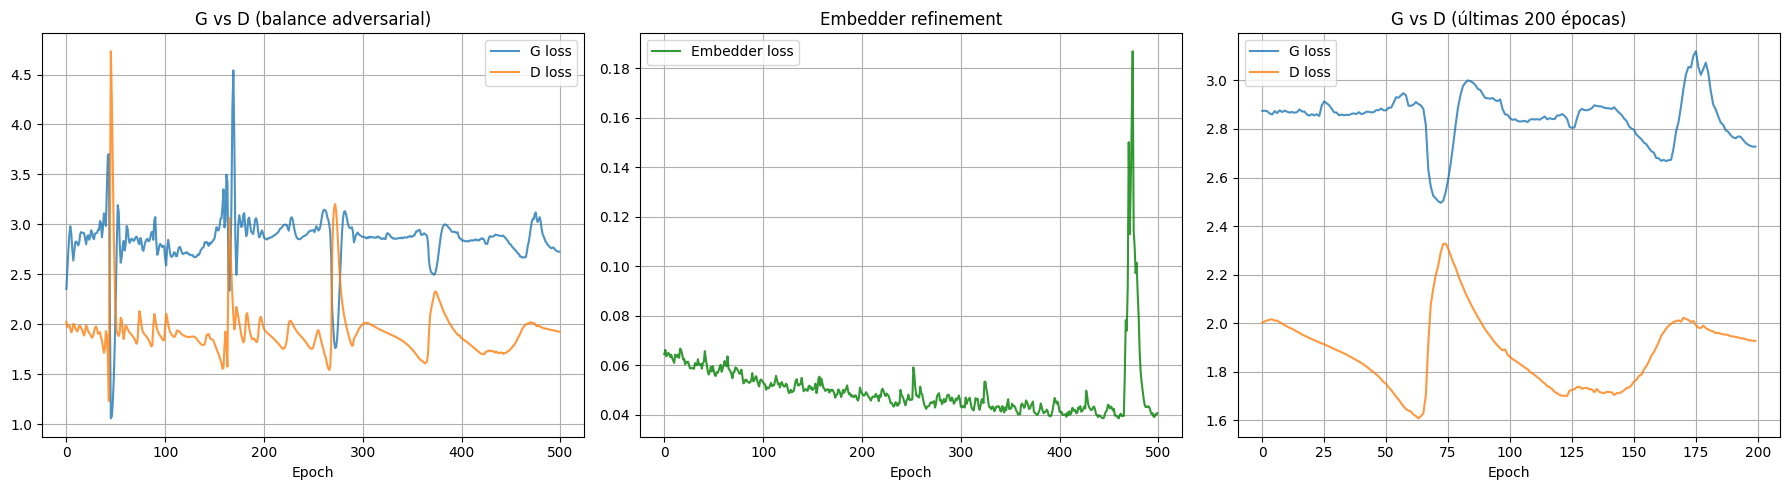

Valores finales:
  G: 2.7275
  D: 1.9272
  E: 0.0406

Diagnóstico del balance adversarial:
  ℹ️  Revisar curvas — el balance puede no ser óptimo.


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(joint_g_history, label="G loss", alpha=0.8)
axes[0].plot(joint_d_history, label="D loss", alpha=0.8)
axes[0].set_title("G vs D (balance adversarial)")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(joint_e_history, label="Embedder loss", color="green", alpha=0.8)
axes[1].set_title("Embedder refinement")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

# Zoom últimas 200 épocas
axes[2].plot(joint_g_history[-200:], label="G loss", alpha=0.8)
axes[2].plot(joint_d_history[-200:], label="D loss", alpha=0.8)
axes[2].set_title("G vs D (últimas 200 épocas)")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("Valores finales:")
print(f"  G: {joint_g_history[-1]:.4f}")
print(f"  D: {joint_d_history[-1]:.4f}")
print(f"  E: {joint_e_history[-1]:.4f}")
print()
print("Diagnóstico del balance adversarial:")
g_final = joint_g_history[-1]
d_final = joint_d_history[-1]
if d_final < 0.1:
    print("  ⚠️  Discriminador dominante — el generador no logra engañarlo bien.")
elif g_final < 0.5 and d_final > 0.5:
    print("  ✅  Balance razonable — el generador está engañando al discriminador.")
else:
    print("  ℹ️  Revisar curvas — el balance puede no ser óptimo.")


## Generación de ventanas sintéticas


In [32]:
n_synth = len(train_timegan_data)

# FIX v2: generación en batches para evitar OOM en GPU con datasets grandes
synthetic_list = []
batch_gen = 256

with torch.no_grad():
    for start in range(0, n_synth, batch_gen):
        end  = min(start + batch_gen, n_synth)
        bs   = end - start
        z    = random_generator(bs, seq_len, latent_dim, device)
        e_hat = generator(z)
        h_hat = supervisor(e_hat)
        x_hat = recovery(h_hat).cpu().numpy()
        synthetic_list.append(x_hat)

synthetic_windows = np.concatenate(synthetic_list, axis=0)

print("Synthetic windows shape:", synthetic_windows.shape)
print("Min/Max:", synthetic_windows.min(), synthetic_windows.max())


Synthetic windows shape: (948, 60, 114)
Min/Max: 5.6075424e-13 1.0


## Separar continuas y discretas sintéticas


In [33]:
n_cont = len(continuous_cols)
n_disc_onehot = total_disc_onehot_dim

synthetic_cont_scaled  = synthetic_windows[:, :, :n_cont]
synthetic_disc_onehot  = synthetic_windows[:, :, n_cont:n_cont + n_disc_onehot]

print("Synthetic continuous:", synthetic_cont_scaled.shape)
print("Synthetic discrete onehot:", synthetic_disc_onehot.shape)


Synthetic continuous: (948, 60, 23)
Synthetic discrete onehot: (948, 60, 91)


In [34]:
synthetic_cont_flat     = synthetic_cont_scaled.reshape(-1, n_cont)
synthetic_cont_physical = scaler_cont_timegan.inverse_transform(synthetic_cont_flat).reshape(synthetic_cont_scaled.shape)

synthetic_cont_physical_flat = synthetic_cont_physical.reshape(-1, n_cont)
synthetic_cont_for_detector  = scaler_cont_detector.transform(synthetic_cont_physical_flat).reshape(synthetic_cont_scaled.shape)

print("Physical scale:", synthetic_cont_physical.shape)
print("For detector:", synthetic_cont_for_detector.shape)


Physical scale: (948, 60, 23)
For detector: (948, 60, 23)


c:\Users\j.manriquec\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Decodificar discretas


In [35]:
def decode_onehot_discrete_sequence(onehot_seq, discrete_cols, discrete_value_maps):
    decoded_rows = []
    for t in range(onehot_seq.shape[0]):
        row, cursor = [], 0
        for col in discrete_cols:
            categories = discrete_value_maps[col]
            k = len(categories)
            block = onehot_seq[t, cursor:cursor+k]
            row.append(categories[int(np.argmax(block))])
            cursor += k
        decoded_rows.append(row)
    return np.array(decoded_rows, dtype=np.float32)

synthetic_disc_raw = np.array([
    decode_onehot_discrete_sequence(synthetic_disc_onehot[i], discrete_cols, discrete_value_maps)
    for i in range(synthetic_disc_onehot.shape[0])
], dtype=np.float32)

print("Synthetic discrete raw:", synthetic_disc_raw.shape)


Synthetic discrete raw: (948, 60, 26)


## Resumen discretas por ventana


In [36]:
def summarize_discrete_windows_from_raw(disc_windows_raw, discrete_cols):
    summary_rows = []
    for w in disc_windows_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            values = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(values).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(values[1:] != values[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(values))
            feats[f"{col}__dominance"]   = pd.Series(values).value_counts(normalize=True).iloc[0]
        summary_rows.append(feats)
    return pd.DataFrame(summary_rows)

synthetic_disc_summary = summarize_discrete_windows_from_raw(synthetic_disc_raw, discrete_cols)
print("Synthetic disc summary:", synthetic_disc_summary.shape)
synthetic_disc_summary.head()


Synthetic disc summary: (948, 104)


,MV101.Status__mode,MV101.Status__transitions,MV101.Status__nunique,MV101.Status__dominance,MV201.Status__mode,MV201.Status__transitions,MV201.Status__nunique,MV201.Status__dominance,MV301.Status__mode,MV301.Status__transitions,...,P4_STATE__nunique,P4_STATE__dominance,P5_STATE__mode,P5_STATE__transitions,P5_STATE__nunique,P5_STATE__dominance,P6_STATE__mode,P6_STATE__transitions,P6_STATE__nunique,P6_STATE__dominance
0,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
1,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
2,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
3,1.0,0,1,1.0,2.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
4,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0


## Compatibilidad con el detector


In [37]:
X_synth_cont = np.transpose(synthetic_cont_for_detector, (0, 2, 1)).astype(np.float32)
X_synth_disc = synthetic_disc_summary.values.astype(np.float32)

print("X_synth_cont for detector:", X_synth_cont.shape)
print("X_synth_disc for detector:", X_synth_disc.shape)


X_synth_cont for detector: (948, 23, 60)
X_synth_disc for detector: (948, 104)


## Visualización PCA y t-SNE

**FIX v2 — Protocolo de visualización corregido:**  
1. Se usa muestreo aleatorio (no primeras N muestras) para evitar sesgar la representación.  
2. PCA preprocessing a 50 componentes antes de t-SNE para datasets de alta dimensión.  
3. `init='pca'` en t-SNE para convergencia estable y reproducible.  
4. Se muestran ambas métricas juntas para diagnóstico rápido.


In [38]:
n_plot = min(1000, len(train_timegan_data), len(synthetic_windows))

rng = np.random.default_rng(SEED)
real_idx  = rng.choice(len(train_timegan_data), n_plot, replace=False)
synth_idx = rng.choice(len(synthetic_windows),  n_plot, replace=False)

real_sample  = train_timegan_data[real_idx].reshape(n_plot, -1)
synth_sample = synthetic_windows[synth_idx].reshape(n_plot, -1)

print(f"Muestras para visualización: {n_plot} reales + {n_plot} sintéticas")
print(f"Dimensión por muestra: {real_sample.shape[1]}")


Muestras para visualización: 948 reales + 948 sintéticas
Dimensión por muestra: 6840


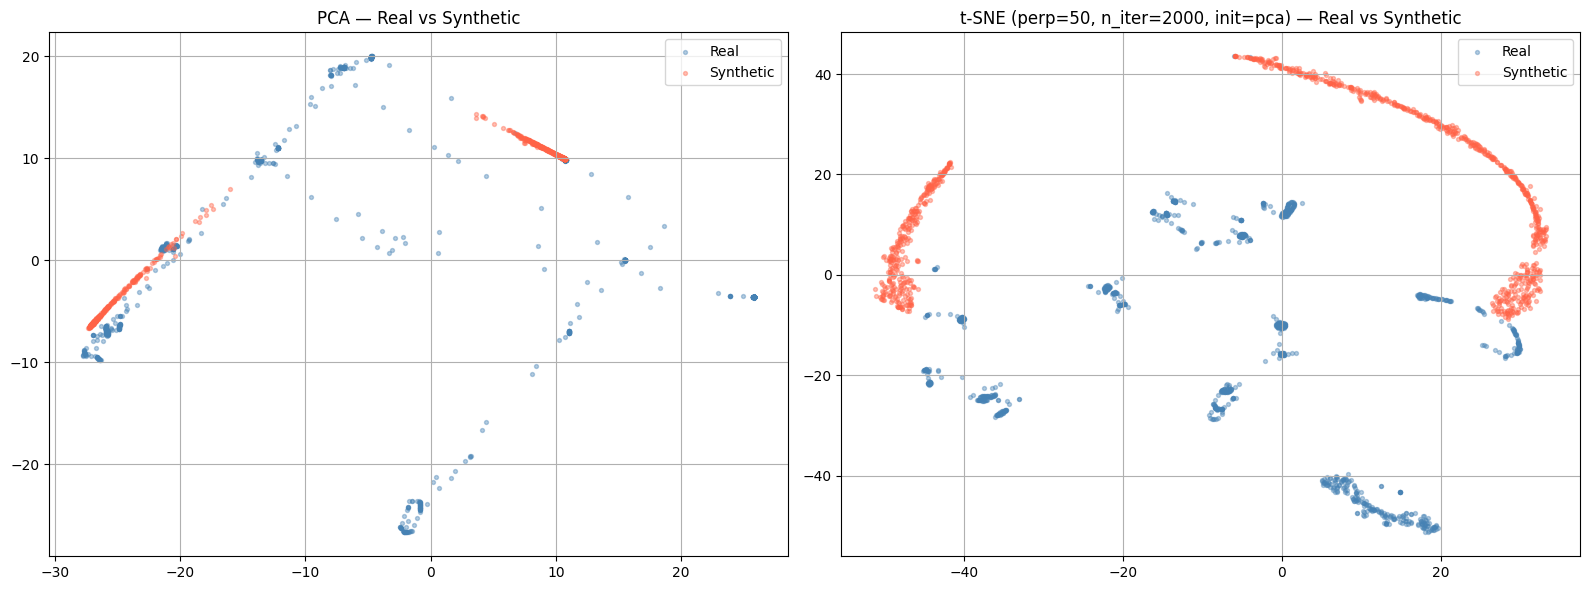

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PCA ---
pca = PCA(n_components=2, random_state=SEED)
pca_real  = pca.fit_transform(real_sample)
pca_synth = pca.transform(synth_sample)

axes[0].scatter(pca_real[:, 0],  pca_real[:, 1],  alpha=0.4, label="Real",      c='steelblue', s=8)
axes[0].scatter(pca_synth[:, 0], pca_synth[:, 1], alpha=0.4, label="Synthetic", c='tomato',    s=8)
axes[0].set_title("PCA — Real vs Synthetic")
axes[0].legend()
axes[0].grid(True)

# --- t-SNE con PCA preprocessing ---
n_pca_pre = min(50, real_sample.shape[1])
pca_pre = PCA(n_components=n_pca_pre, random_state=SEED)
combined_reduced = pca_pre.fit_transform(np.vstack([real_sample, synth_sample]))

perp = min(50, n_plot // 5)
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=perp,
    max_iter=2000,
    init="pca",
    learning_rate="auto"
)
tsne_out   = tsne.fit_transform(combined_reduced)
tsne_real  = tsne_out[:n_plot]
tsne_synth = tsne_out[n_plot:]

axes[1].scatter(tsne_real[:, 0],  tsne_real[:, 1],  alpha=0.4, label="Real",      c='steelblue', s=8)
axes[1].scatter(tsne_synth[:, 0], tsne_synth[:, 1], alpha=0.4, label="Synthetic", c='tomato',    s=8)
axes[1].set_title(f"t-SNE (perp={perp}, n_iter=2000, init=pca) — Real vs Synthetic")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("tsne_pca_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Métricas cuantitativas de calidad

El t-SNE y PCA son visualizaciones cualitativas. Para la tesis, estas métricas  
cuantitativas son más rigurosas y complementan la evaluación visual.


In [41]:
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------------
# TSTR (Train Synthetic Test Real) + Train Real Test Synthetic:
# Métrica clave para tesis: si los datos sintéticos son buenos,
# un clasificador entrenado en ellos debería distinguir real/sintético
# con AUC ~0.5 (indistinguibles). AUC alto = fácil de distinguir = mal.
# ------------------------------------------------------------------

X_all = np.vstack([real_sample, synth_sample])
y_all = np.array([0] * n_plot + [1] * n_plot)  # 0=real, 1=sintético

# Split 80/20
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
y_proba = clf.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, y_proba)

print("=" * 50)
print("Métrica de discriminabilidad (Train-Discriminate)")
print(f"  AUC discriminador = {auc:.4f}")
print(f"  Interpretación:")
if auc < 0.6:
    print("  ✅  < 0.6 → Datos sintéticos de alta calidad (indistinguibles)")
elif auc < 0.75:
    print("  ⚠️  0.6-0.75 → Calidad media (algunas diferencias detectables)")
else:
    print("  ❌  > 0.75 → Baja calidad (el modelo sigue colapsado)")
print("=" * 50)


Métrica de discriminabilidad (Train-Discriminate)
  AUC discriminador = 1.0000
  Interpretación:
  ❌  > 0.75 → Baja calidad (el modelo sigue colapsado)


In [42]:
# ------------------------------------------------------------------
# Distancia de distribuciones: media y varianza por feature
# ------------------------------------------------------------------
real_cont_flat  = train_cont_windows.reshape(-1, n_cont)
synth_cont_flat = synthetic_cont_scaled.reshape(-1, n_cont)

mean_diff = np.abs(real_cont_flat.mean(axis=0) - synth_cont_flat.mean(axis=0))
std_diff  = np.abs(real_cont_flat.std(axis=0)  - synth_cont_flat.std(axis=0))

print(f"Diferencia de medias (promedio sobre features): {mean_diff.mean():.4f}")
print(f"Diferencia de stds   (promedio sobre features): {std_diff.mean():.4f}")
print()
print("Top 5 features con mayor diferencia de media:")
top5_idx = np.argsort(mean_diff)[-5:][::-1]
for i in top5_idx:
    print(f"  {continuous_cols[i]}: diff_mean={mean_diff[i]:.4f}, diff_std={std_diff[i]:.4f}")


Diferencia de medias (promedio sobre features): 0.1131
Diferencia de stds   (promedio sobre features): 0.0791

Top 5 features con mayor diferencia de media:
  LIT401.Pv: diff_mean=0.4221, diff_std=0.0305
  LIT101.Pv: diff_mean=0.3125, diff_std=0.2416
  AIT502.Pv: diff_mean=0.2757, diff_std=0.3238
  AIT501.Pv: diff_mean=0.2623, diff_std=0.0422
  PIT502.Pv: diff_mean=0.2073, diff_std=0.3570


## Visualización real vs sintético por feature


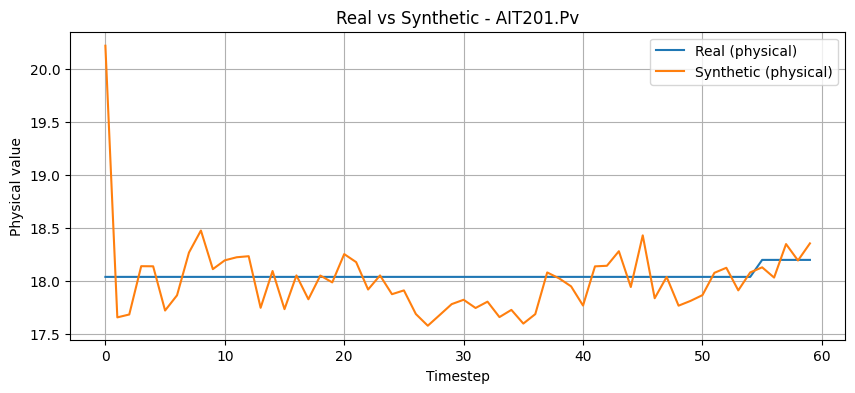

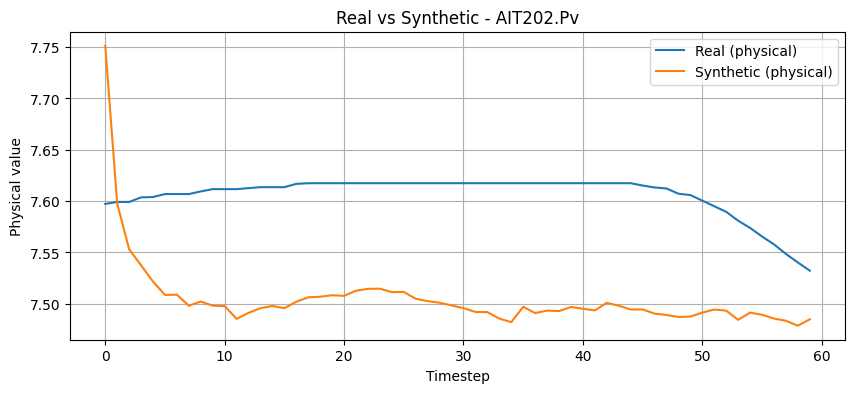

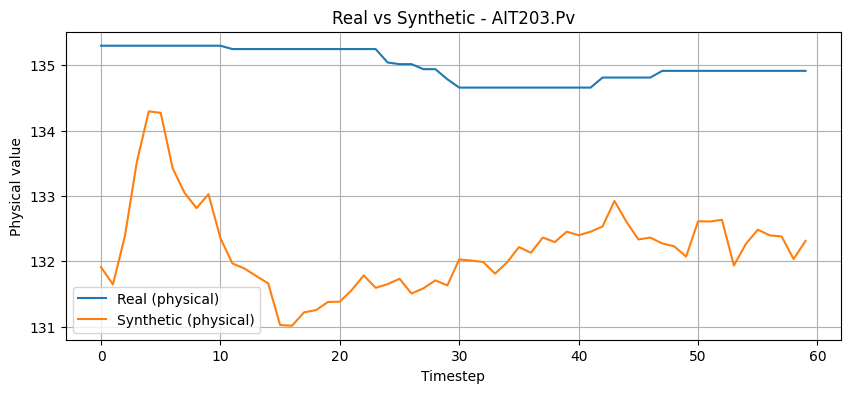

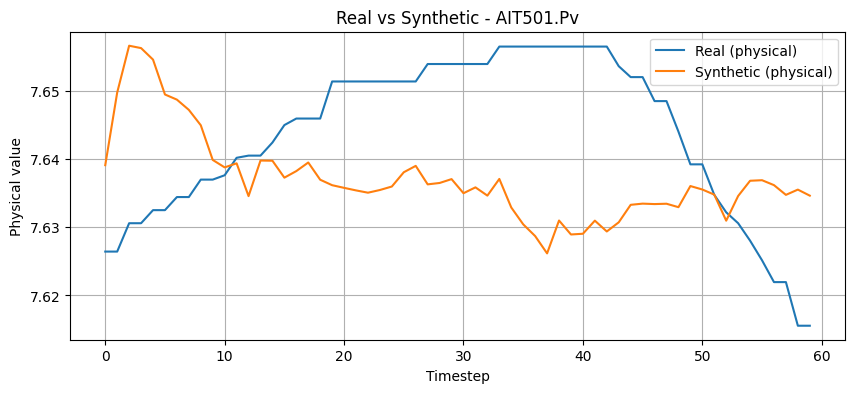

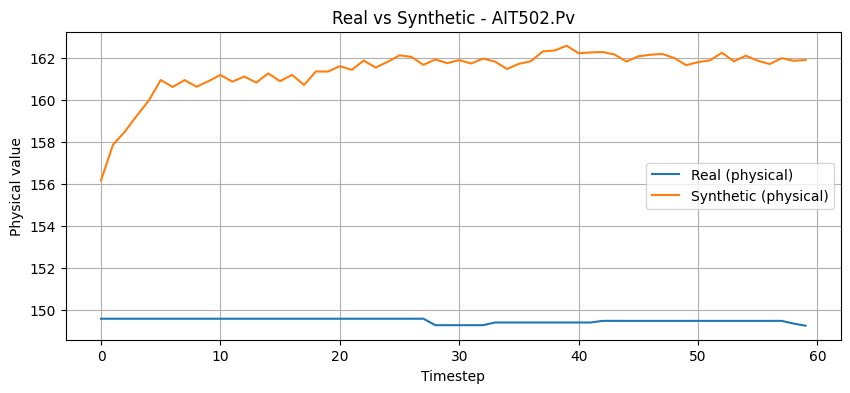

In [43]:
def plot_real_vs_synth_continuous_physical(
    train_cont_windows, synthetic_cont_physical, scaler_cont_timegan, col_idx, col_name, n_steps=60
):
    real_seq_scaled  = train_cont_windows[0, :n_steps, :]
    real_seq_physical = scaler_cont_timegan.inverse_transform(real_seq_scaled)[:, col_idx]
    synth_seq_physical = synthetic_cont_physical[0, :n_steps, col_idx]

    plt.figure(figsize=(10, 4))
    plt.plot(real_seq_physical,  label="Real (physical)")
    plt.plot(synth_seq_physical, label="Synthetic (physical)")
    plt.title(f"Real vs Synthetic - {col_name}")
    plt.xlabel("Timestep")
    plt.ylabel("Physical value")
    plt.grid(True)
    plt.legend()
    plt.show()

for i, col in enumerate(continuous_cols[:5]):
    plot_real_vs_synth_continuous_physical(
        train_cont_windows, synthetic_cont_physical, scaler_cont_timegan, i, col
    )


## Guardado de artefactos


In [44]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts").mkdir(parents=True, exist_ok=True)


In [45]:
torch.save(embedder.state_dict(),      TIMEGAN_MODEL_DIR / "embedder.pt")
torch.save(recovery.state_dict(),      TIMEGAN_MODEL_DIR / "recovery.pt")
torch.save(generator.state_dict(),     TIMEGAN_MODEL_DIR / "generator.pt")
torch.save(supervisor.state_dict(),    TIMEGAN_MODEL_DIR / "supervisor.pt")
torch.save(discriminator.state_dict(), TIMEGAN_MODEL_DIR / "discriminator.pt")
print("Modelos guardados.")


Modelos guardados.


In [46]:
joblib.dump(scaler_cont_timegan,  PROJECT_ROOT / "artifacts" / "scalers" / "timegan_conv1d_hybrid_scaler_cont_minmax.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_conv1d_hybrid_scaler_cont_detector.pkl")


['C:\\Users\\j.manriquec\\ics-synthetic-data-augmentation\\artifacts\\scalers\\timegan_conv1d_hybrid_scaler_cont_detector.pkl']

In [47]:
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in discrete_value_maps.items()}, f, indent=4)


In [48]:
timegan_config = {
    "aligned_detector": "conv1d_hybrid_ae",
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "window_size": WINDOW_SIZE,
    "stride_detector": STRIDE,
    "stride_timegan": TIMEGAN_STRIDE,
    "warmup": WARMUP,
    "seed": SEED,
    "hidden_dim": hidden_dim,
    "latent_dim": latent_dim,
    "num_layers": num_layers,
    "epochs_embedder": epochs_embedder,
    "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint,
    "batch_size": BATCH_SIZE,
    "gamma": gamma, "eta": eta,
    "lambda_r": lambda_r, "lambda_s": lambda_s, "lambda_m": lambda_m,
    "train_timegan_shape": list(train_timegan_data.shape),
    "synthetic_windows_shape": list(synthetic_windows.shape),
    "auc_discriminability": float(auc),
}

with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(timegan_config, f, indent=4)


In [49]:
pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "generator_loss": joint_g_history,
    "discriminator_loss": joint_d_history,
    "embedder_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

np.save(TIMEGAN_MODEL_DIR / "synthetic_windows.npy",          synthetic_windows)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_scaled.npy",      synthetic_cont_scaled)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_physical.npy",    synthetic_cont_physical)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_for_detector.npy", synthetic_cont_for_detector)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_raw.npy",         synthetic_disc_raw)
synthetic_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synthetic_disc_summary.csv", index=False)

print("✅ Todos los artefactos guardados en:", TIMEGAN_MODEL_DIR.resolve())


✅ Todos los artefactos guardados en: C:\Users\j.manriquec\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
